In [1]:
import os
import sys
import rootutils
import pandas as pd
import numpy as np

# Setup the project root indicator
root = rootutils.setup_root(search_from=os.getcwd(), indicator=".project-root", pythonpath=True)
print(f"Project root located at: {root}")

Project root located at: C:\Users\ashre\Documents\lemurs-modeling


In [2]:
# Evaluation Metrics
from sklearn.metrics import (
    balanced_accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# --- Classifiers (For Classification Sweeps) ---
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# --- Regressors (For Regression Sweeps) ---
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.svm import SVR

# --- Common Non-Sklearn Additions for Sweeps ---
# (Uncomment if needed, usually essential for a modern sweep)
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
# from catboost import CatBoostClassifier, CatBoostRegressor

In [3]:
from src.utils.database_service import DatabaseService
from dotenv import load_dotenv

# Load environment variables (.env)
load_dotenv()

# Initialize and connect
db = DatabaseService()
if db.connect():
    print("Successfully connected to the database!")
    # Extract a small sample from the proximity table
    proximity_df = db.extract_from_database("proximity")
    print(f"Proximity dataframe shape: {proximity_df.shape}")
    print("\nFirst few rows of raw Proximity (Bluetooth scan) data:")
    display(proximity_df.head())
    db.disconnect()
else:
    print("Database connection failed. Check your .env file.")

Successfully connected to the database!
Proximity dataframe shape: (16056, 4)

First few rows of raw Proximity (Bluetooth scan) data:


,id,app_user_id,number_of_devices,timestamp
0,1,2,38,2025-11-06 15:45:22.193
1,2,2,38,2025-11-06 15:45:22.193
2,3,5,48,2025-11-14 16:39:43.013
3,4,5,48,2025-11-14 16:39:43.013
4,5,5,36,2025-11-15 10:15:19.344


In [26]:
def preprocess_proximity(df: pd.DataFrame) -> pd.DataFrame:
    """Preprocesses raw Proximity (Bluetooth Scan) data.
    
    Args:
        df: Raw DataFrame from proximity table.
    Returns:
        Cleaned DataFrame satisfying the DataModule contract.
    """
    # 1. Rename 'timestamp' to 'start_timestamp' to satisfy the DataModule contract
    df = df.rename(columns={"timestamp": "start_timestamp"})
    
    # 2. Filter out invalid/negative device counts
    df = df[df["number_of_devices"] >= 0].copy()

    # 3. DO ANY OTHER DATA PROCESSING/CLEANING STEPS HERE (REMOVE DUPLICATES, IMPUTE VALUES, ETC)
    df = df.drop_duplicates(subset=['app_user_id', 'number_of_devices', 'start_timestamp'])
    
    return df

# Verify the preprocessor locally
db.connect()
raw_df = db.extract_from_database("proximity")
db.disconnect()

cleaned_df = preprocess_proximity(raw_df)
print("Columns after preprocessing:", list(cleaned_df.columns))
display(cleaned_df.head())

Columns after preprocessing: ['id', 'app_user_id', 'number_of_devices', 'start_timestamp']


,id,app_user_id,number_of_devices,start_timestamp
0,1,2,38,2025-11-06 15:45:22.193
2,3,5,48,2025-11-14 16:39:43.013
4,5,5,36,2025-11-15 10:15:19.344
5,6,5,60,2025-11-15 10:30:31.541
6,7,5,65,2025-11-15 17:51:09.777


In [ ]:
for user in cleaned_df.app_user_id:
    user_df = cleaned_df[cleaned_df['app_user_id']==user].sort_values(by='start_timestamp')
    user_df["hr"] = pd.to_datetime(user_df["start_timestamp"]).dt.hour
    user_df["date"] = pd.to_datetime(user_df["start_timestamp"]).dt.strftime("%Y-%m-%d")
    user_df = user_df[]



In [ ]:
user_df = cleaned_df[cleaned_df['app_user_id']==2].sort_values(by='start_timestamp')
user_df["hr"] = pd.to_datetime(user_df["start_timestamp"]).dt.hour
user_df["date"] = pd.to_datetime(user_df["start_timestamp"]).dt.strftime("%Y-%m-%d")
for i in range(len(user_df)):
    if user_df["date"].iloc[i] == user_df["date"].iloc[i+1]:
        print(0)

In [5]:
import inspect
from hydra.utils import instantiate
import hydra
from omegaconf import OmegaConf
from pathlib import Path

# look at configs/data/aggregator to select which one you want
LABEL_CHOICE = "suicide_risk"
# leave below frozen
YAML_PATH = Path(f"../configs/data/aggregator/{LABEL_CHOICE}.yaml")

# Load the config file that is the data label aggregator
cfg = OmegaConf.load(YAML_PATH)

# Instantiate the aggregator
aggregator = hydra.utils.instantiate(cfg)

from src.data.components.label_aggregators import MeanAggregator 
from src.data.components.samplers import RollingSampler, OffsetSampler
from sklearn.preprocessing import StandardScaler

# Sampler: 24-hour lookback window with hourly resampling

## can repeat the process for another scaler if want 
# SCALER_CHOICE = "subject_standard"
# SCALER_YAML_PATH = f"../configs/data/scaler/{SCALER_CHOICE}.yaml"
# scaler_cfg = OmegaConf.load(SCALER_YAML_PATH)
# sampler = hydra.utils.instantiate(scaler_cfg)

sampler = OffsetSampler(start_offset_hours=-72, end_offset_hours=0, resample_freq='1h')

# Scaler: standard scaler
scaler = StandardScaler()

In [24]:
from src.data.health_datamodule import HealthDataModule

# Register modalities, columns, and preprocessors
# Note: 'proximity' is mapped to database column 'number_of_devices'
modalities = ["proximity"]
modality_cols = {"proximity": "number_of_devices"}
preprocessors = {"proximity": preprocess_proximity}

datamodule = HealthDataModule(
    aggregator=aggregator,
    sampler=sampler,
    scaler=scaler,
    preprocessors=preprocessors,
    modalities=modalities,
    batch_size=8,
    split_mode="longitudinal",               # Disjoint populations (no user leakage between splits)
    train_val_test_split=(0.7, 0.15, 0.15),
    random_state=42
)

# Trigger setup to fetch, preprocess, split, and scale data
datamodule.setup()

print("✅ DataModule setup completed successfully!")
print(f"Train samples: {len(datamodule.data_train)}")
print(f"Val samples:   {len(datamodule.data_val)}")
print(f"Test samples:  {len(datamodule.data_test)}")

Filtering out 80 duplicate survey responses submitted within 10 minutes with identical answers.
Collapsed 2054 survey responses into 1088 unique daily samples per user.


✅ DataModule setup completed successfully!
Train samples: 737
Val samples:   157
Test samples:  187


In [7]:
sample = next(iter(datamodule.train_dataloader()))
print(sample)

[tensor([[[-0.1947],
         [-0.1947],
         [-0.1947],
         [-0.1947],
         [-0.1947],
         [-0.1947],
         [-0.1947],
         [-0.1947],
         [-0.1947],
         [ 0.3364],
         [-0.1947],
         [-0.1947],
         [-0.1947],
         [-0.1947],
         [-0.1947],
         [ 0.9657],
         [-0.1947],
         [-0.1947],
         [-0.1947],
         [-0.1947],
         [-0.1947],
         [-0.1947],
         [-0.1947],
         [-0.1947],
         [-0.1947],
         [-0.1947],
         [-0.1947],
         [-0.1947],
         [-0.1947],
         [-0.1947],
         [-0.1947],
         [-0.1947],
         [-0.1947],
         [-0.1947],
         [-0.1947],
         [-0.1947],
         [-0.1947],
         [-0.1947],
         [-0.1947],
         [-0.1947],
         [-0.1947],
         [ 2.0278],
         [-0.1947],
         [-0.1947],
         [-0.1947],
         [-0.1947],
         [-0.1947],
         [-0.1947],
         [-0.1947],
         [-0.1947],

In [8]:
import torch
import numpy as np
from torch.utils.data import DataLoader, Dataset

def convert_to_numpy(data_source, batch_size=32):
    """Converts a DataLoader or Dataset into a tuple of numpy arrays (X, y).
    
    Automatically flattens features from [B, T, F] to [B, T*F].
    """
    # If the input is a Dataset, wrap it in a DataLoader for efficient batching
    if isinstance(data_source, Dataset):
        dataloader = DataLoader(data_source, batch_size=batch_size, shuffle=False)
    else:
        dataloader = data_source
        
    X_list = []
    y_list = []
    
    for batch in dataloader:
        x, y = batch[0], batch[1]
        
        # Convert PyTorch tensors to numpy
        if isinstance(x, torch.Tensor):
            x = x.cpu().numpy()
        if isinstance(y, torch.Tensor):
            y = y.cpu().numpy()
            
        # Ensure we have a batch dimension
        if x.ndim == 1:
            x = np.expand_dims(x, axis=0)
        if np.isscalar(y) or y.ndim == 0:
            y = np.array([y])
            
        # Flatten time/feature dimensions: [B, T, F] -> [B, T*F]
        if x.ndim > 2:
            x = x.reshape(x.shape[0], -1)
            
        X_list.append(x)
        y_list.append(y)
        
    X_all = np.concatenate(X_list, axis=0)
    y_all = np.concatenate(y_list, axis=0)
    
    return X_all, y_all

# Extract the training, validation, and test datasets
X_train, y_train = convert_to_numpy(datamodule.train_dataloader())
X_val, y_val = convert_to_numpy(datamodule.val_dataloader())
X_test, y_test = convert_to_numpy(datamodule.test_dataloader())


In [9]:
print(X_train.shape)
print(y_train.shape)

(756, 72)
(756,)


In [ ]:
y_test

In [19]:
from sklearn.model_selection import RandomizedSearchCV

def tune_model(model, param_dist, X_train, y_train,
               scoring="f1", cv=10, n_iter=25, n_jobs=-1, verbose=1):
    """
    Generic hyperparameter tuning function using RandomizedSearchCV.
    
    Parameters
    ----------
    model : estimator
        Any sklearn-compatible estimator (XGBClassifier, RandomForestClassifier, etc.)
    param_dist : dict
        Dictionary of hyperparameter search space.
    X_train, y_train : array-like
        Training data.
    scoring : str
        Metric to optimize (default: F1).
    cv : int
        Number of cross-validation folds.
    n_iter : int
        Number of random search iterations.
    n_jobs : int
        Parallel jobs.
    verbose : int
        Verbosity level.

    Returns
    -------
    best_model : estimator
        The tuned model with best hyperparameters.
    search : RandomizedSearchCV object
        Full search object (contains cv results, best params, etc.)
    """
    
    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_dist,
        n_iter=n_iter,
        scoring=scoring,
        cv=cv,
        n_jobs=n_jobs,
        verbose=verbose,
        random_state=42
    )
    
    search.fit(X_train, y_train)
    print("Best Params:", search.best_params_)
    print("Best CV Score:", search.best_score_)
    
    return search.best_estimator_, search


Fitting 10 folds for each of 25 candidates, totalling 250 fits


c:\Users\ashre\anaconda3\lib\site-packages\joblib\externals\loky\process_executor.py:702: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Params: {'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 1, 'colsample_bytree': 0.7}
Best CV Score: 0.11323676323676324
      Metric     Value
0         BA  0.523681
1  Precision  0.285714
2     Recall  0.083333
3   F1 Score  0.129032


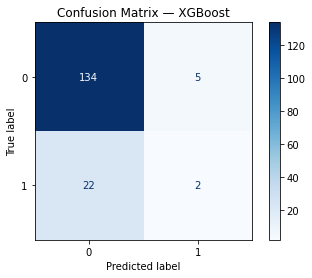

In [ ]:
# Hyperparameters
param_dist_xgb = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.6, 0.7, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 1.0],
    "gamma": [0, 0.5, 1, 2],
    "min_child_weight": [1, 3, 5, 7],
}

# Model
base_model = XGBClassifier(tree_method="hist", eval_metric="logloss")

model, search_obj = tune_model(
    model=base_model,
    param_dist=param_dist_xgb,
    X_train=X_train,
    y_train=y_train,
    scoring="f1"
)

# Predictions
y_pred = model.predict(X_test)

# Metrics
ba   = balanced_accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
cm   = confusion_matrix(y_test, y_pred)

results = pd.DataFrame({
    "Metric": ["BA", "Precision", "Recall", "F1 Score"],
    "Value":  [ba, prec, rec, f1]
})

print(results)

import matplotlib.pyplot as plt
# Display
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix — XGBoost")
plt.show()

Fitting 10 folds for each of 25 candidates, totalling 250 fits
Best Params: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 20, 'bootstrap': False}
Best CV Score: 0.1838092780972038
      Metric     Value
0         BA  0.561751
1  Precision  0.400000
2     Recall  0.166667
3   F1 Score  0.235294


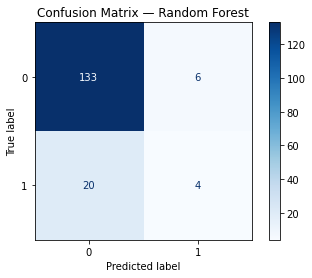

In [22]:
# Hyperparameters
param_dist_rf = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True, False],
}


# Model
base_model = RandomForestClassifier()

model, search_obj = tune_model(
    model=base_model,
    param_dist=param_dist_rf,
    X_train=X_train,
    y_train=y_train,
    scoring="f1"
)

# Predictions
y_pred = model.predict(X_test)

# Metrics
ba   = balanced_accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
cm   = confusion_matrix(y_test, y_pred)

results = pd.DataFrame({
    "Metric": ["BA", "Precision", "Recall", "F1 Score"],
    "Value":  [ba, prec, rec, f1]
})

print(results)

# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix — Random Forest")
plt.show()

c:\Users\ashre\anaconda3\lib\site-packages\sklearn\model_selection\_search.py:285: UserWarning: The total space of parameters 16 is smaller than n_iter=25. Running 16 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 10 folds for each of 16 candidates, totalling 160 fits
Best Params: {'kernel': 'rbf', 'gamma': 'scale', 'C': 0.1}
Best CV Score: 0.25702258045462917
      Metric     Value
0         BA  0.569544
1  Precision  0.228571
2     Recall  0.333333
3   F1 Score  0.271186


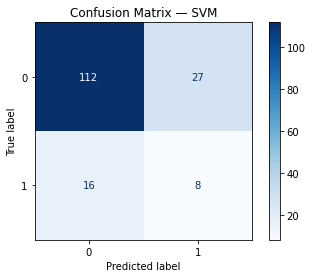

In [23]:
# Hypereparameters
param_dist_svm = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}


# Model
base_model = SVC(kernel='rbf', C=10, gamma=0.1, class_weight='balanced')

model, search_obj = tune_model(
    model=base_model,
    param_dist=param_dist_svm,
    X_train=X_train,
    y_train=y_train,
    scoring="f1"
)

# Predictions
y_pred = model.predict(X_test)

# Metrics
ba   = balanced_accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
cm   = confusion_matrix(y_test, y_pred)

results = pd.DataFrame({
    "Metric": ["BA", "Precision", "Recall", "F1 Score"],
    "Value":  [ba, prec, rec, f1]
})

print(results)

# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix — SVM")
plt.show()

In [ ]:
# Pipeline: scaling + logistic regression
log_model = LogisticRegression(
        penalty='l2',
        C=1.0,
        solver='lbfgs',
        max_iter=500,
        class_weight='balanced'   # helps if classes are imbalanced
    )

log_model.fit(X_train, y_train)

# Predictions
y_pred = log_model.predict(X_test)

# Metrics
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='binary')
rec  = recall_score(y_test, y_pred, average='binary')
f1   = f1_score(y_test, y_pred, average='binary')
cm   = confusion_matrix(y_test, y_pred)

# Display
results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Value":  [acc, prec, rec, f1]
})

print(results)

# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix — Logistic Regression")
plt.show()
